In [ ]:
import pandas as pd

train_path = "/data/UNSW_NB15_training-set.csv"
test_path = "/data/UNSW_NB15_testing-set.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

display(train_df.head())

Training shape: (175341, 45)
Testing shape: (82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [ ]:
print(train_df.columns.tolist())

['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


In [ ]:
train_df.info()
train_df.isnull().sum()
train_df.nunique().sort_values()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  si

,0
is_sm_ips_ports,2
label,2
is_ftp_login,4
ct_ftp_cmd,4
ct_state_ttl,5
dttl,6
dwin,7
state,9
attack_cat,10
ct_flw_http_mthd,11


In [ ]:
print(train_df["label"].value_counts())
print(train_df["attack_cat"].value_counts())
print(train_df["label"].value_counts(normalize=True) * 100)

label
1    119341
0     56000
Name: count, dtype: int64
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64
label
1    68.062233
0    31.937767
Name: proportion, dtype: float64


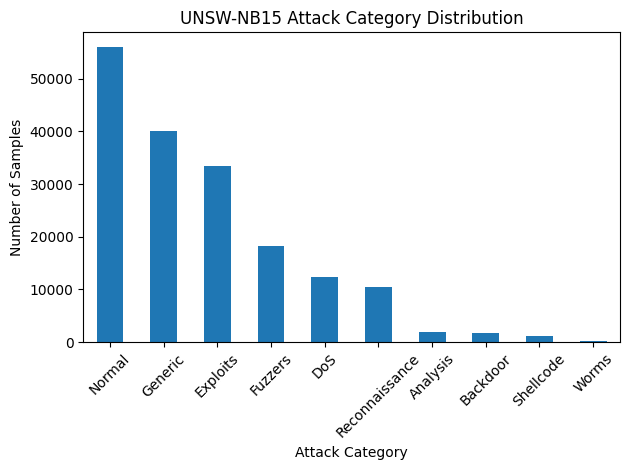

In [ ]:
import matplotlib.pyplot as plt

train_df["attack_cat"].value_counts().plot(kind="bar")

plt.title("UNSW-NB15 Attack Category Distribution")
plt.xlabel("Attack Category")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

print("\nTraining columns:", len(train_df.columns))
print("Testing columns:", len(test_df.columns))

print("\nMissing values in label:")
print(train_df["label"].isna().sum())

print("\nDuplicate rows:")
print(train_df.duplicated().sum())

Training rows: 175341
Testing rows: 82332

Training columns: 45
Testing columns: 45

Missing values in label:
0

Duplicate rows:
0


In [ ]:
print(train_df["label"].value_counts(dropna=False))

label
1    119341
0     56000
Name: count, dtype: int64


In [ ]:
print(train_df["attack_cat"].value_counts(dropna=False))

attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


In [ ]:
print("Training:", train_df.shape)
print("Testing:", test_df.shape)

print("\nMissing label:")
print(train_df["label"].isna().sum())

print("\nDuplicate rows:")
print(train_df.duplicated().sum())

print("\nRows with any missing values:")
print(train_df.isna().any(axis=1).sum())

print("\nMissing-value rows:")
display(train_df[train_df.isna().any(axis=1)])

Training: (175341, 45)
Testing: (82332, 45)

Missing label:
0

Duplicate rows:
0

Rows with any missing values:
0

Missing-value rows:


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label


Check test dataset

In [ ]:
print("Test missing values:")
print(test_df.isna().sum()[test_df.isna().sum() > 0])

print("\nTest rows with any missing values:")
print(test_df.isna().any(axis=1).sum())

print("\nTest duplicates:")
print(test_df.duplicated().sum())

Test missing values:
Series([], dtype: int64)

Test rows with any missing values:
0

Test duplicates:
0


Define Baseline Task:
label = 0 → Normal
label = 1 → Attack